In [1]:
import glob
import geopandas as gpd
import os
import urllib.request
import shutil
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

In [2]:



# Caminho onde os arquivos serão baixados
download_dir = os.path.abspath("../zip_2020")  # ou use DATA_2020
os.makedirs(download_dir, exist_ok=True)

# Configurações do Chrome para download automático
options = webdriver.ChromeOptions()
prefs = {
    "download.default_directory": download_dir,  # onde salvar
    "download.prompt_for_download": False,       # não perguntar
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True,
    "profile.default_content_settings.popups": 0
}
options.add_experimental_option("prefs", prefs)

# Inicia o driver com as opções configuradas
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
# driver.set_page_load_timeout(300)


In [ ]:
# driver = webdriver.Chrome(executable_path="./chromedriver")  # Optional argument, if not specified will search path.

In [3]:
cwd = os.getcwd()

# options = Options()
# options.add_experimental_option("prefs", {
#     "download.default_directory": os.path.join(cwd, "ortofotos"),
#     "download.prompt_for_download": False,
#     "download.directory_upgrade": True,
#     "safebrowsing.enabled": True
# })

# # O argumento correto agora é "options", não "chrome_options"
# driver = webdriver.Chrome(options=options)

In [4]:
DATA_2020 = "../LiDAR-Sampa-2020"
DATA_2017 = "../LiDAR-Sampa-2017"
# "https://laz-m3dc-pmsp.s3-sa-east-1.amazonaws.com/MDS_color_3442-122.laz"

In [5]:
gdf_articulacao = gpd.read_file('zip://data/SIRGAS_SHP_quadriculamdt.zip!SIRGAS_SHP_quadriculamdt')

In [6]:
# driver = webdriver.Chrome(chrome_options=options)

In [7]:
glob.glob(f'{DATA_2020}/MDS_*.laz')

['../LiDAR-Sampa-2020/MDS_3433-363_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3431-333_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3433-362_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3431-154_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3443-341_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3431-332_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3315-333_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3235-451_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3212-422_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3234-164_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3333-413_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3236-134_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3331-443_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3211-321_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3315-154_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3212-423_1000.laz',
 '../LiDAR-Sampa-2020/MDS_4315-251_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3314-461_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3333-412_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3332-341_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3315-332_1000.laz',
 '../LiDAR-Sampa-2020/MDS_3331-442

In [8]:
def wait_for_downloads(download_dir="../zip_2020", timeout=300):
    seconds = 0
    while any(fname.endswith(".crdownload") for fname in os.listdir(download_dir)):
        time.sleep(1)
        seconds += 1
        if seconds > timeout:
            break
            # raise TimeoutError("Download levou tempo demais.")

In [9]:
for i, quadricula in gdf_articulacao.iterrows():
    q = quadricula.qmdt_cod
    d = f"https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C{q}.zip&arqTipo=MAPA_ARTICULACAO"
    if len(glob.glob(f'{DATA_2020}/MDS_{q}*.laz')) < 1:
        print(d)
        driver.get(d)
        time.sleep(60)
        wait_for_downloads()
        # print(f'baixando {q}')
        # urllib.request.urlretrieve(d, f'{DATA_2020}/{q.split("-")[0]}/MDS_{q}_1000.laz')
    # break

https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C3443-464.zip&arqTipo=MAPA_ARTICULACAO
https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C3445-232.zip&arqTipo=MAPA_ARTICULACAO
https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C2326-323.zip&arqTipo=MAPA_ARTICULACAO
https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C2344-342.zip&arqTipo=MAPA_ARTICULACAO
https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C3343-353.zip&arqTipo=MAPA_ARTICULACAO
https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=DownloadMapaArticulacao&arq=MDS_2020%5C3345-121.zip&arqTipo=MAPA_ARTICULACAO
https://geosampa.prefeitura.sp.gov.br/PaginasPublicas/downloadIfr.aspx?orig=Downlo

In [85]:
zip_files = glob.glob(f'{DATA_2020}/*.zip')

In [88]:
len(zip_files)

262

In [87]:
for file in zip_files:
    !unzip '{file}' -d '{DATA_2020}'

Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/4311-454.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_4311-454_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/3446-264.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_3446-264_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/2342-364.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_2342-364_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/2342-361.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_2342-361_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/3446-332.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_3446-332_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/4311-121.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_4311-121_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/4311-443.zip
  inflating: /media/fernando/DATA/LiDAR-Sampa-2020/MDS_4311-443_1000.laz  
Archive:  /media/fernando/DATA/LiDAR-Sampa-2020/

In [78]:
len(glob.glob(f'{DATA_2020}/*.zip'))

579

In [60]:
for file in glob.glob(f'{DATA_2020}/*.zip'):
    print(file)
    os.remove(file)

In [69]:
for file in glob.glob(f'{DATA_2020}/**/MDS_*.laz'):
    print(f'movendo ... {file.split("/")[-1]}')
    os.replace(file, f'{DATA_2020}/{file.split("/")[-1]}')

movendo ... MDS_3322-243_1000.laz
movendo ... MDS_3322-344_1000.laz
movendo ... MDS_3322-442_1000.laz
movendo ... MDS_3322-431_1000.laz
movendo ... MDS_3322-161_1000.laz
movendo ... MDS_3322-461_1000.laz
movendo ... MDS_3322-223_1000.laz
movendo ... MDS_3322-451_1000.laz
movendo ... MDS_3322-164_1000.laz
movendo ... MDS_3322-263_1000.laz
movendo ... MDS_3322-364_1000.laz
movendo ... MDS_3322-463_1000.laz
movendo ... MDS_3322-452_1000.laz
movendo ... MDS_3322-433_1000.laz
movendo ... MDS_3322-454_1000.laz
movendo ... MDS_3322-153_1000.laz
movendo ... MDS_3322-334_1000.laz
movendo ... MDS_3322-262_1000.laz
movendo ... MDS_3322-123_1000.laz
movendo ... MDS_3322-252_1000.laz
movendo ... MDS_3322-312_1000.laz
movendo ... MDS_3322-212_1000.laz
movendo ... MDS_3322-122_1000.laz
movendo ... MDS_3322-342_1000.laz
movendo ... MDS_3322-323_1000.laz
movendo ... MDS_3322-224_1000.laz
movendo ... MDS_3322-412_1000.laz
movendo ... MDS_3322-112_1000.laz
movendo ... MDS_3322-354_1000.laz
movendo ... MD

## 2017

In [6]:
import geopandas as gpd
import urllib.request
import glob
import os
from concurrent.futures import ThreadPoolExecutor

In [7]:
# Função para baixar um arquivo individualmente
def baixar_arquivo(q):
    arquivo_local = os.path.join(DATA_2017, f"MDS_color_{q}.laz")
    if not os.path.exists(arquivo_local):
        url = f"https://laz-m3dc-pmsp.s3-sa-east-1.amazonaws.com/MDS_color_{q}.laz"
        try:
            print(f"Baixando {q}")
            urllib.request.urlretrieve(url, arquivo_local)
        except Exception as e:
            print(f"Erro ao baixar {q}: {e}")

In [8]:
# Lista de códigos que precisam ser baixados
codigos = [
    row.qmdt_cod
    for _, row in gdf_articulacao.iterrows()
    if not os.path.exists(os.path.join(DATA_2017, f"MDS_color_{row.qmdt_cod}.laz"))
]

In [9]:
# Execução paralela com 12 threads
with ThreadPoolExecutor(max_workers=12) as executor:
    executor.map(baixar_arquivo, codigos)

In [10]:
# for i, quadricula in gdf_articulacao.iterrows():
#     q = quadricula.qmdt_cod
#     d = f"https://laz-m3dc-pmsp.s3-sa-east-1.amazonaws.com/MDS_color_{q}.laz"
#     if len(glob.glob(f'{DATA_2017}/MDS_color_{q}.laz')) < 1:
#         print(f'baixando {q}')
#         urllib.request.urlretrieve(d, f'{DATA_2017}/MDS_color_{q}.laz')

In [11]:
gdf_articulacao.shape

(5362, 2)

# 2020 - acertando os dados

In [19]:
arquivos_laz = glob.glob('../Voo_LiDAR_2020/**/**/**')
destino = '../LiDAR-Sampa-2020/'

In [20]:
len(arquivos_laz)

4618

In [ ]:
for i in arquivos_laz:
    print(os.path.basename(i))
    shutil.copy(i, os.path.join(destino, os.path.basename(i)))
    # break

In [39]:
scms = [i[24:-9] for i in glob.glob(f'{destino}/*.laz')]

<Axes: >

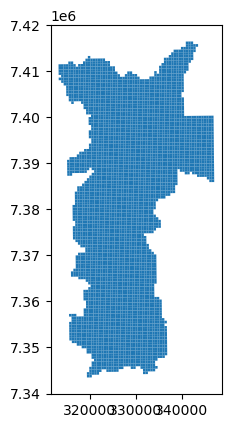

In [42]:
# Conferir a presença dos arquivos de 2020
gdf_articulacao[gdf_articulacao.qmdt_cod.isin(scms)].plot()